# Práctica 5: Ejercicios propuestos
# Inteligencia Artificial
# Grado en Ingeniería Informática - Ingeniería del Software
# Universidad de Sevilla

In [1]:
import numpy as np

In [25]:
from gymnasium import Env
from gymnasium.spaces import Box, Discrete, Dict
from gymnasium.wrappers import RecordEpisodeStatistics, TimeLimit

In [3]:
from tqdm import tqdm

In [4]:
import matplotlib.pyplot as plt

### Ejercicio 1

El objetivo de este ejercicio es implementar generalizaciones del entorno de ejemplo usado en la práctica. Se recuerda que ese entorno pretende simular un robot que se desplaza por una cuadrícula con 3 filas y 4 columnas, con el objetivo de alcanzar la celda superior derecha de la cuadrícula, pero evitando, en la medida de lo posible, pasar por la celda inmediatamente inferior a esa celda objetivo. Además, la celda de la segunda fila y segunda columna no es accesible.

<img src="Cuadrícula.png" width="150" height="120" style="display: block; margin: 0 auto">

En cada celda, las acciones aplicables son desplazarse una celda en cada una de las 4 posibles direcciones (arriba, abajo, izquierda y derecha). Sin embargo, es posible que, en lugar de moverse en la dirección indicada, el robot se mueva en una dirección perpendicular a ella. La probabilidad de que el robot se mueva en la dirección indicada es de 0.8, mientras que, para cada dirección perpendicular, la probabilidad de que se mueva en esa dirección es de 0.1.

Si al tratar de desplazarse el robot choca con el borde exterior de la cuadrícula o con la celda no accesible, entonces no se desplaza y permanece en la celda donde se encontraba.

Como se pretende que el robot aprenda a alcanzar la celda objetivo lo antes posible, se establece una recompensa de -0.04 para cada celda. Para que también aprenda a evitar la celda inferior a la objetivo, se establece una recompensa de -1 para esa celda. Las acciones no tienen coste.

#### Apartado 1

Completar, sustituyendo `...` por código adecuado, la siguiente implementación del entorno que permite establecer las dimensiones de la cuadrícula. La celda que debe alcanzar el robot es la celda superior derecha y la celda que debe evitar es la inmediatamente inferior a ella. Por simplicidad, se considera que la posición inicial del robot es una celda aleatoria, distinta de la celda objetivo y de la celda no accesible.

In [21]:
class EntornoCuadrícula1(Env):
    def __init__(self, anchura, altura):
        """Los argumentos anchura y altura indican, respectivamente, el número
        de columnas y de filas de la cuadrícula."""
        self.anchura = anchura
        self.altura = altura
        self.espacio_de_estados = Box(low=np.array([0, 0]),
                                      high=np.array([anchura - 1, altura - 1]),
                                      dtype=int)
        self.espacio_de_acciones = Discrete(n=4)
        
    _efectos_de_acciones = {0: np.array([[0, 1], [-1, 0], [1, 0]]),
                            1: np.array([[0, -1], [-1, 0], [1, 0]]),
                            2: np.array([[-1, 0], [0, 1], [0, -1]]),
                            3: np.array([[1, 0], [0, 1], [0, -1]])}
    
    def obten_posibles_movimientos(self, acción):
        return EntornoCuadrícula1._efectos_de_acciones[acción]
    
    def reset(self, seed=None, options=None):
        """Genera una posición aleatoria inicial distinta de la celda no
        accesible y de la celda objetivo."""
        if seed is not None:
            super().reset(seed=seed)
            self.espacio_de_estados.seed(seed)
            self.espacio_de_acciones.seed(seed)

        posicion_objetivo = np.array([self.anchura - 1, self.altura - 1], dtype=int)
        celda_no_accesible = np.array([1, 1], dtype=int)
        
        posicion_inicial = self.espacio_de_estados.sample()
        while (np.array_equal(posicion_inicial, celda_no_accesible) or
               np.array_equal(posicion_inicial, posicion_objetivo)):
            posicion_inicial = self.espacio_de_estados.sample()

        self._estado_actual = posicion_inicial
        return self._estado_actual, {}
    
    def step(self, action):
        """Mueve el robot aplicando la acción indicada y controlando que el
        robot no se salga de la cuadrícula ni ocupe la celda no accesible.
        Devuelve la señal de episodio terminado cuando el robot alcanza la
        celda objetivo."""
        assert self.espacio_de_acciones.contains(action), 'Acción no válida'

        posibles_movimientos = self.obten_posibles_movimientos(action)
        idx_mov = self.np_random.choice(3, p=[0.8, 0.1, 0.1])

        movimiento = posibles_movimientos[idx_mov]

        estado_candidato = self._estado_actual + movimiento

        celda_no_accesible = np.array([1, 1], dtype=int)
        fuera = (
            estado_candidato[0] < 0 or estado_candidato[0] >= self.anchura or
            estado_candidato[1] < 0 or estado_candidato[1] >= self.altura
        )

        if fuera or np.array_equal(estado_candidato, celda_no_accesible):
            nuevo_estado = self._estado_actual.copy()
        else: 
            nuevo_estado = estado_candidato

        posicion_objetivo = np.array([self.anchura - 1, self.altura - 1], dtype=int)
        celda_a_evitar = np.array([self.anchura - 1, self.altura - 2], dtype=int)

        recompensa = -1.0 if np.array_equal(nuevo_estado, celda_a_evitar) else -0.04
        terminado = np.array_equal(nuevo_estado, posicion_objetivo)

        self._estado_actual = nuevo_estado
        return self._estado_actual, recompensa, terminado, False, {}

#### Apartado 2

Completar, sustituyendo `...` por código adecuado, la siguiente implementación del entorno que, además, permite establecer las celdas no accesibles. La celda que debe alcanzar el robot es la celda superior derecha y la celda que debe evitar es la inmediatamente inferior a ella. Por simplicidad, se considera que la posición inicial del robot es una celda aleatoria, distinta de la celda objetivo y de las celdas no accesibles especificadas.

Nota: considérese el uso del [método `tolist`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.tolist.html) de los arrays de NumPy.

In [11]:
class EntornoCuadrícula2(Env):
    def __init__(self, anchura, altura, no_accesibles):
        """Los argumentos anchura y altura indican, respectivamente, el número
        de columnas y de filas de la cuadrícula. El argumento no_accesibles es
        una lista de celdas no accesibles, cada una de ellas indicada como una
        lista de sus coordenadas."""
        self.anchura = anchura
        self.altura = altura
        self.no_accesibles = no_accesibles
        self.espacio_de_estados = Box(low=np.array([0, 0]),
                                      high=np.array([anchura - 1, altura - 1]),
                                      dtype=int)
        self.espacio_de_acciones = Discrete(n=4)
        
    _efectos_de_acciones = {0: np.array([[0, 1], [-1, 0], [1, 0]]),
                            1: np.array([[0, -1], [-1, 0], [1, 0]]),
                            2: np.array([[-1, 0], [0, 1], [0, -1]]),
                            3: np.array([[1, 0], [0, 1], [0, -1]])}
    
    def obtén_posibles_movimientos(self, acción):
        return EntornoCuadrícula2._efectos_de_acciones[acción]
    
    def reset(self, seed=None, options=None):
        """Genera una posición aleatoria inicial distinta de las celdas no
        accesibles y de la celda objetivo."""
        if seed is not None:
            super().reset(seed=seed)
            self.espacio_de_estados.seed(seed)
            self.espacio_de_acciones.seed(seed)
        
        # Aquí empieza mi código
        posicion_objetivo = [self.anchura - 1, self.altura - 1]

        posicion_inicial = self.espacio_de_estados.sample()
        while (posicion_inicial.tolist() in self.no_accesibles or
               posicion_inicial.tolist() == posicion_objetivo):
            posicion_inicial = self.espacio_de_estados.sample()
        # Aquí termina mi código
        
        self._estado_actual = posicion_inicial
        return self._estado_actual, {}
    
    def step(self, action):
        """Mueve el robot aplicando la acción indicada y controlando que el
        robot no se salga de la cuadrícula ni ocupe ninguna de las celdas no
        accesibles. Devuelve la señal de episodio terminado cuando el robot
        alcanza la celda objetivo."""
        ########################
        # Aquí empieza mi código
        ########################

        # 1. validamos la acción
        assert self.espacio_de_acciones.contains(action), 'Acción no válida'

        #2. Tomamos cual será el siguiente movimiento de transición con probabilidades 
        posibles_movimientos = self.obtén_posibles_movimientos(action)
        indice_movimiento = self.np_random.choice(3, p=[0.8, 0.1, 0.1])
        movimiento = posibles_movimientos[indice_movimiento]

        #3. Aplicamos el movimiento
        estado_candidato = self._estado_actual + movimiento

        #4. Validamos si el estado candidato es válido o salió de la cuadrícula
        fuera = (
            estado_candidato[0] < 0 or estado_candidato[0] >= self.anchura or
            estado_candidato[1] < 0 or estado_candidato[1] >= self.altura
        )

        #5. Si está fuera o en una celda no accesible, nos quedamos en el estado actual
        if fuera or estado_candidato.tolist() in self.no_accesibles:
            nuevo_estado = self._estado_actual.copy()
        else:
            nuevo_estado = estado_candidato

        #6. Estas celdas se podrían refactorizar como atributos de la clase para no tener que definirlas en cada paso
        posicion_objetivo = np.array([self.anchura - 1, self.altura - 1], dtype=int)
        celda_a_evitar = np.array([self.anchura - 1, self.altura - 2], dtype=int)

        #7. Definimos la recompensa
        if np.array_equal(nuevo_estado, celda_a_evitar):
            recompensa = -1.0
        else:
            recompensa = -0.04

        # ¿El episodio ha terminado?
        terminado = np.array_equal(nuevo_estado, posicion_objetivo)
        
        ########################
        # Aquí termina mi código
        ########################
        
        self._estado_actual = nuevo_estado
        return self._estado_actual, recompensa, terminado, False, {}

c2 = EntornoCuadrícula2(4, 4, [[1, 1], [2, 1], [1, 2]])
estado, _ = c2.reset(seed=42)
print("Estado inicial:", estado)
print("Step acción 0:", c2.step(action=0))

Estado inicial: [3 1]
Step acción 0: (array([3, 2]), -1.0, False, False, {})


#### Apartado 3

Completar, sustituyendo `...` por código adecuado, la siguiente implementación del entorno que, además, en cada episodio elige aleatoriamente, de entre las celdas de la fila superior, aquella que debe alcanzar el robot. Correspondientemente, la celda que debe evitar el robot en cada episodio es la inmediatamente inferior a la celda objetivo. Por simplicidad, se considera que la posición inicial del robot en cada episodio es una celda aleatoria, distinta de la celda objetivo y de las celdas no accesibles especificadas.

Nota: obsérvese el uso de un [espacio de estados de tipo `Dict`](https://gymnasium.farama.org/api/spaces/composite/#gymnasium.spaces.Dict) para implementar el hecho de que, en este entorno, los estados deben guardar tanto la posición del robot como la columna de la celda objetivo.

In [13]:
class EntornoCuadrícula3(Env):
    def __init__(self, anchura, altura, no_accesibles):
        """Los argumentos anchura y altura indican, respectivamente, el número
        de columnas y de filas de la cuadrícula. El argumento no_accesibles es
        una lista de celdas no accesibles, cada una de ellas indicada como una
        lista de sus coordenadas."""
        self.anchura = anchura
        self.altura = altura
        self.no_accesibles = no_accesibles
        self.espacio_de_estados = Dict({
            'posición': Box(low=np.array([0, 0]),
                            high=np.array([anchura - 1, altura - 1]),
                            dtype=int),
            'objetivo': Discrete(n=anchura)
        })
        self.espacio_de_acciones = Discrete(n=4)
        
    _efectos_de_acciones = {0: np.array([[0, 1], [-1, 0], [1, 0]]),
                            1: np.array([[0, -1], [-1, 0], [1, 0]]),
                            2: np.array([[-1, 0], [0, 1], [0, -1]]),
                            3: np.array([[1, 0], [0, 1], [0, -1]])}
    
    def obtén_posibles_movimientos(self, acción):
        return self._efectos_de_acciones[acción]
    
    def reset(self, seed=None, options=None):
        """Genera una columna aleatoria para la celda objetivo y una posición
        aleatoria inicial distinta de las celdas no accesibles y de la celda
        objetivo."""
        if seed is not None:
            super().reset(seed=seed)
            self.espacio_de_estados.seed(seed)
            self.espacio_de_acciones.seed(seed)

        ########################
        # Aquí empieza mi código
        ########################

        # 1. Elegimos aleatoriamente la columna de la celda objetivo
        columna_objetivo = self.espacio_de_estados['objetivo'].sample()

        # 2. Construimos la celda objetivo (siempre en la fila superior)
        posicion_objetivo = [columna_objetivo, self.altura - 1]

        # 3. Muestreamos una posición inicial válida
        posición_inicial = self.espacio_de_estados['posición'].sample()

        # 4. Repetimos mientras la posición sea no accesible o la celda objetivo
        while (posición_inicial.tolist() in self.no_accesibles or
               posición_inicial.tolist() == posicion_objetivo):
            posición_inicial = self.espacio_de_estados['posición'].sample()

        ########################
        # Aquí termina mi código
        ########################
        
        self._posición_actual = posición_inicial
        self._objetivo_actual = columna_objetivo
        return ({'posición': self._posición_actual,
                 'objetivo': self._objetivo_actual},
                {})
    
    def step(self, action):
        """Mueve el robot aplicando la acción indicada y controlando que el
        robot no se salga de la cuadrícula ni ocupe ninguna de las celdas no
        accesibles. Devuelve la señal de episodio terminado cuando el robot
        alcanza la celda objetivo para el episodio."""
        ########################
        # Aquí empieza mi código
        ########################

        # 1. Validamos que la acción pertenezca al espacio de acciones
        assert self.espacio_de_acciones.contains(action), 'Acción no válida'

        # 2. Elegimos el movimiento estocástico según las probabilidades
        posibles_movimientos = self.obtén_posibles_movimientos(action)
        indice_movimiento = self.np_random.choice(3, p=[0.8, 0.1, 0.1])
        movimiento = posibles_movimientos[indice_movimiento]

        # 3. Aplicamos el movimiento a la posición actual
        posicion_candidata = self._posición_actual + movimiento

        # 4. Comprobamos si la posición candidata sale de la cuadrícula
        fuera = (
            posicion_candidata[0] < 0 or posicion_candidata[0] >= self.anchura or
            posicion_candidata[1] < 0 or posicion_candidata[1] >= self.altura
        )

        # 5. Si es inválida (fuera o no accesible), el robot no se mueve
        if fuera or posicion_candidata.tolist() in self.no_accesibles:
            nueva_posición = self._posición_actual.copy()
        else:
            nueva_posición = posicion_candidata

        # 6. Definimos la celda objetivo y la celda a evitar para este episodio
        posicion_objetivo = np.array([self._objetivo_actual, self.altura - 1], dtype=int)
        celda_a_evitar = np.array([self._objetivo_actual, self.altura - 2], dtype=int)

        # 7. Calculamos la recompensa
        if np.array_equal(nueva_posición, celda_a_evitar):
            recompensa = -1.0
        else:
            recompensa = -0.04

        # 8. El episodio termina si alcanzamos la celda objetivo
        terminado = np.array_equal(nueva_posición, posicion_objetivo)

        ########################
        # Aquí termina mi código
        ########################
        
        self._posición_actual = nueva_posición
        return ({'posición': self._posición_actual,
                 'objetivo': self._objetivo_actual},
                recompensa, terminado, False, {})

c3 = EntornoCuadrícula2(4, 4, [[1, 1], [1, 2]])
estado, _ = c3.reset(seed=42)
print("Estado inicial:", estado)
print("Step acción 0:", c3.step(action=0))

Estado inicial: [3 1]
Step acción 0: (array([3, 2]), -1.0, False, False, {})


#### Apartado 4

Una vez realizado cada uno de los apartados anteriores, llevar a cabo diversas pruebas con distintos tamaños de cuadrícula, distintas listas de celdas no accesibles y fijando o no la celda objetivo. Para ello se proporcionan la clase `AgenteQLearning`, que implementa un agente capaz de aplicar el algoritmo Q-Learning a cada una de las tres versiones del entorno, la función `representa_politica`, capaz de escribir por pantalla cada una de las políticas aprendidas por el agente, y la función `visualiza_serie_temporal_de_episodios`, para representar gráficamente el aprendizaje del agente a medida que se van generando los episodios.

In [14]:
class AgenteQLearning:
    def __init__(self, entorno, gamma, alfa, epsilon):
        self.entorno = entorno
        self.gamma = gamma
        self.alfa = alfa
        self.epsilon = epsilon
        if isinstance(entorno.unwrapped.espacio_de_estados, Dict):
            self.tabla_q = np.zeros((entorno.unwrapped.anchura,
                                     entorno.unwrapped.anchura,
                                     entorno.unwrapped.altura,
                                     4))
        else:
            self.tabla_q = np.zeros((entorno.unwrapped.anchura,
                                     entorno.unwrapped.altura,
                                     4))
    
    def _preprocesa_estado(self, estado):
        if isinstance(self.entorno.unwrapped.espacio_de_estados, Dict):
            estado = np.insert(estado['posición'], 0, estado['objetivo'])
        return estado
    
    def elige_acción(self, estado):
        espacio_de_acciones = self.entorno.unwrapped.espacio_de_acciones
        if self.entorno.np_random.random() < self.epsilon:
            acción_elegida = espacio_de_acciones.sample()
        else:
            estado = self._preprocesa_estado(estado)
            acción_elegida = np.argmax(
                self.tabla_q[tuple(estado)]
            )
        return acción_elegida
    
    def actualiza_tabla_q(self, estado, acción, recompensa, nuevo_estado):
        estado = self._preprocesa_estado(estado)
        nuevo_estado = self._preprocesa_estado(nuevo_estado)
        diferencia_temporal = (
            recompensa + 
            self.gamma * np.max(self.tabla_q[tuple(nuevo_estado)]) -
            self.tabla_q[tuple(estado)][acción]
        )
        self.tabla_q[tuple(estado)][acción] += self.alfa * diferencia_temporal
    
    def ejecuta_algoritmo(self, num_episodios):
        episodios = tqdm(range(1, num_episodios + 1), ncols=100)
        for episodio in episodios:
            estado, _ = self.entorno.reset()
            while True:
                acción = self.elige_acción(estado)
                (nuevo_estado, recompensa,
                 terminado, truncado, _) = self.entorno.step(acción)
                self.actualiza_tabla_q(estado, acción, recompensa, nuevo_estado)
                if terminado or truncado:
                    break
                estado = nuevo_estado
        return np.argmax(self.tabla_q, axis=-1)

In [15]:
def representa_acción(acción):
    representaciones_de_acciones = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    return representaciones_de_acciones[acción]
representa_acción = np.vectorize(representa_acción)

def representa_política(entorno, política):
    if isinstance(entorno.espacio_de_estados, Dict):
        for objetivo in range(entorno.anchura):
            print(f'Columna objetivo: {objetivo}')
            representación = representa_acción(política[objetivo])
            representación[objetivo, entorno.altura - 1] = 'T'
            for celda in entorno.no_accesibles:
                representación[tuple(celda)] = 'X'
            print(np.flipud(representación.T))
            print()
    else:
        representación = representa_acción(política)
        representación[entorno.anchura - 1, entorno.altura - 1] = 'T'
        if hasattr(entorno, 'no_accesibles'):
            for celda in entorno.no_accesibles:
                representación[tuple(celda)] = 'X'
        else:
            representación[1, 1] = 'X'
        print(np.flipud(representación.T))
        print()

In [16]:
def visualiza_serie_temporal_de_episodios(recompensas, longitudes):
    num_episodios = len(recompensas)
    índices_episodios = np.arange(1, num_episodios + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
    ax1.plot(índices_episodios, np.cumsum(recompensas) / índices_episodios)
    ax1.set_title('Promedio de las recompensas\nacumuladas de los episodios')
    ax1.set_xlabel('Episodio')
    ax1.set_ylabel('Promedio')
    ax2.plot(índices_episodios, np.cumsum(longitudes) / índices_episodios)
    ax2.set_title('Promedio de las longitudes\nde los episodios')
    ax2.set_xlabel('Episodio')
    ax2.set_ylabel('Promedio')

Entonces se pueden hacer pruebas como las siguientes:

  0%|                                                                      | 0/1000 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 606.18it/s]


[['→' '→' '→' '→' 'T']
 ['→' '↑' '↑' '←' '↑']
 ['↑' 'X' '↑' '←' '↓']
 ['↑' '→' '↑' '←' '←']]



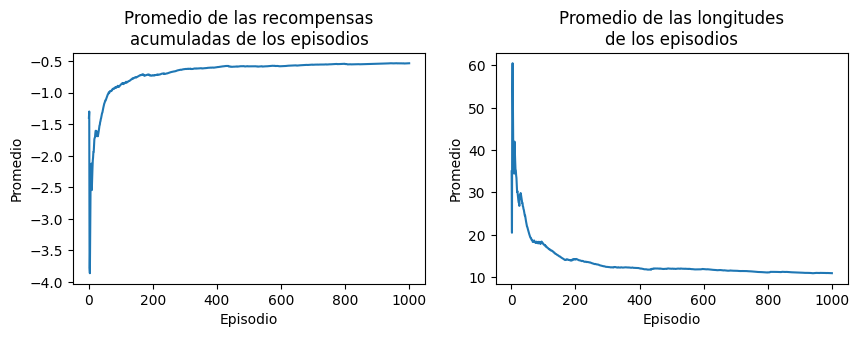

In [22]:
cuadrícula_5x4 = EntornoCuadrícula1(5, 4)
cuadrícula_5x4_con_registro = RecordEpisodeStatistics(
    cuadrícula_5x4,
    buffer_length=1000
)
cuadrícula_5x4_con_registro.reset(seed=3958723)

agente = AgenteQLearning(cuadrícula_5x4_con_registro,
                         gamma=0.9, alfa=0.5, epsilon=0.25)
política_aprendida = agente.ejecuta_algoritmo(num_episodios=1000)
representa_política(cuadrícula_5x4, política_aprendida)

recompensas = cuadrícula_5x4_con_registro.return_queue
longitudes = cuadrícula_5x4_con_registro.length_queue
visualiza_serie_temporal_de_episodios(recompensas, longitudes)

### Te explico lo que estás viendo

Lo que estás viendo resume cómo aprende el agente Q-Learning durante los 1000 episodios.

1. Barra de progreso (0/1000 → 1000/1000)
Es simplemente tqdm indicando que terminó el entrenamiento.  
El número tipo 606 it/s es la velocidad de iteración.

2. Matriz con flechas y letras (política aprendida)
Esa salida es la política final en la cuadrícula:
- flechas: acción que el agente considera mejor en cada celda
- T: celda objetivo (terminal)
- X: celda bloqueada/no accesible

En tu impresión se ve como caracteres raros, pero conceptualmente son esas flechas.

3. Gráfica izquierda: Promedio de recompensas acumuladas
Se calcula como promedio acumulado hasta cada episodio:
- al principio es muy negativa (peor desempeño)
- luego sube y se estabiliza (menos negativa)

Interpretación: el agente cada vez recibe “menos castigo” por episodio, o sea encuentra rutas mejores hacia el objetivo y evita más la celda penalizada.

4. Gráfica derecha: Promedio de longitudes de episodio
Mide cuántos pasos tarda en terminar cada episodio (promedio acumulado):
- empieza alto (muchos pasos, comportamiento torpe/exploratorio)
- baja de forma clara y se estabiliza

Interpretación: el agente llega al objetivo en menos pasos, señal de aprendizaje.

Conclusión
Tus dos curvas son las esperadas en un entrenamiento correcto:
- recompensa media acumulada mejora
- longitud media de episodio disminuye
- y la política final ya muestra direcciones coherentes hacia T evitando X.


In [ ]:
cuadrícula_5x4 = EntornoCuadrícula2(5, 4,
                                    [[1, 1], [1, 2], [3, 1], [3, 2]])
cuadrícula_5x4_con_registro = RecordEpisodeStatistics(
    cuadrícula_5x4,
    buffer_length=1000
)
cuadrícula_5x4_con_registro.reset(seed=3958723)

agente = AgenteQLearning(cuadrícula_5x4_con_registro,
                         gamma=0.9, alfa=0.5, epsilon=0.25)
política_aprendida = agente.ejecuta_algoritmo(num_episodios=1000)
representa_política(cuadrícula_5x4, política_aprendida)

recompensas = cuadrícula_5x4_con_registro.return_queue
longitudes = cuadrícula_5x4_con_registro.length_queue
visualiza_serie_temporal_de_episodios(recompensas, longitudes)

In [ ]:
cuadrícula_5x4 = EntornoCuadrícula3(5, 4,
                                    [[1, 1], [1, 2], [3, 1], [3, 2]])
cuadrícula_5x4_con_registro = RecordEpisodeStatistics(
    cuadrícula_5x4,
    buffer_length=1000
)
cuadrícula_5x4_con_registro.reset(seed=3958723)

agente = AgenteQLearning(cuadrícula_5x4_con_registro,
                         gamma=0.9, alfa=0.5, epsilon=0.25)

política_aprendida = agente.ejecuta_algoritmo(num_episodios=1000)
representa_política(cuadrícula_5x4, política_aprendida)

recompensas = cuadrícula_5x4_con_registro.return_queue
longitudes = cuadrícula_5x4_con_registro.length_queue
visualiza_serie_temporal_de_episodios(recompensas, longitudes)

### Ejercicio 2

Jack gestiona dos ubicaciones para una empresa de alquiler de coches a nivel nacional. Cada una de esas ubicaciones tiene una capacidad máxima de 20 coches. Cada día laborable ocurre lo siguiente:

- Para ayudar a garantizar que los automóviles estén disponibles donde se necesitan, antes de abrir traslada hasta 5 coches de una ubicación a otra, con un coste de 2€ por cada coche trasladado.
- En cada ubicación se alquila una cantidad aleatoria de coches según una distribución de Poisson de parámetro $\lambda = 3$ en la primera ubicación y $\lambda=4$ en la segunda ubicación. Jack gana 10€ por cada coche alquilado, pero el exceso de solicitudes sobre la cantidad de coches disponibles en la ubicación es negocio perdido.
- En cada ubicación se devuelve una cantidad aleatoria de coches según una distribución de Poisson de parámetro $\lambda = 3$ en la primera ubicación y $\lambda=2$ en la segunda ubicación. El exceso de coches sobre la capacidad máxima de cada ubicación se devuelve a la compañía nacional (es decir, ya no se tienen en cuenta en el problema). Los coches devueltos deben revisarse y limpiarse, por lo que no se pueden volver a alquilar hasta el día siguiente.

Jack desea saber cuál sería la cantidad óptima de coches que debería trasladar de una ubicación a otra cada día, según la cantidad de coches que hubiera en cada ubicación.

#### Apartado 1

Completar, sustituyendo `...` por código adecuado, la siguiente implementación de un entorno de Gymnasium. Debe tenerse en cuenta lo siguiente:

- El espacio de estados debe implementarse como el producto cartesiano $[0, 20] \times [0, 20]$. Cada par $(N_{1}, N_{2})$ de ese espacio representará que hay $N_{1}$ coches en la primera ubicación y $N_{2}$ coches en la segunda ubicación.
- El espacio de acciones debe implementarse como el conjunto $\{-5, -4, \dotsc, 4, 5\}$. Cada elemento $a$ de ese espacio representará que se trasladan $|a|$ coches, de la primera ubicación a la segunda si $a$ es positivo, o de la segunda ubicación a la primera si $a$ es negativo.
- El estado inicial de cada episodio debe ser un elemento aleatorio del espacio de estados.
- Una acción $a$ es aplicable a un estado si hay al menos $|a|$ coches en la ubicación de partida. Al aplicar una acción, después de trasladar la cantidad correspondiente de coches, el exceso sobre la capacidad máxima de la ubicación de llegada se devuelve a la compañía nacial.

Nota: el método `_determina_acciones_aplicables` devuelve una máscara (un array binario) indicando qué acciones son aplicables al estado actual. La idea es usarlo en los métodos `reset` y `step` para que devuelvan esa máscara en el diccionario de información.

In [23]:
class AlquilerDeCochesEnv(Env):
    def __init__(self):
        self.espacio_de_estados = Box(low=np.array([0, 0]), high=np.array([20, 20]), dtype=int)
        self.espacio_de_acciones = Discrete(n=11)
        self.observation_space = self.espacio_de_estados
        self.action_space = self.espacio_de_acciones

    def _determina_acciones_aplicables(self):
        return np.array([-self._estado_actual[1] <= a and a <= self._estado_actual[0] for a in range(-5, 6)], dtype=np.int8)

    def reset(self, seed=None, options=None):
        if seed is not None:
            super().reset(seed=seed)
            self.espacio_de_estados.seed(seed)
            self.espacio_de_acciones.seed(seed)

        self._estado_actual = self.espacio_de_estados.sample()
        return self._estado_actual, {'aplicables': self._determina_acciones_aplicables()}

    def step(self, action):
        assert self.espacio_de_acciones.contains(action), 'Acción no válida'

        traslado = action - 5
        coches_1, coches_2 = self._estado_actual

        if traslado > 0:
            coches_1 -= traslado
            coches_2 += traslado
        elif traslado < 0:
            traslado = -traslado
            coches_1 += traslado
            coches_2 -= traslado

        coches_1 = min(max(coches_1, 0), 20)
        coches_2 = min(max(coches_2, 0), 20)

        solicitudes_1 = self.np_random.poisson(3)
        solicitudes_2 = self.np_random.poisson(4)
        alquileres_1 = min(solicitudes_1, coches_1)
        alquileres_2 = min(solicitudes_2, coches_2)
        recompensa = 10 * (alquileres_1 + alquileres_2) - 2 * abs(action - 5)

        coches_1 = min(coches_1 - alquileres_1 + self.np_random.poisson(3), 20)
        coches_2 = min(coches_2 - alquileres_2 + self.np_random.poisson(2), 20)
        self._estado_actual = np.array([coches_1, coches_2], dtype=int)

        return self._estado_actual, recompensa, False, False, {'aplicables': self._determina_acciones_aplicables()}

#### Apartado 2

Aplicar el algoritmo Q-learning para ayudar a Jack a determinar la mejor cantidad de coches a trasladar cada día. Debe tenerse en cuenta que para obtener una política que se aproxime a la política óptima es necesario usar un factor de aprendizaje $\alpha$ suficientemente pequeño y que el algoritmo realice una gran cantidad $N$ de pasos.

Nótese que en este problema no hay ningún estado terminal. Es por ello que la aplicación del algoritmo puede abordarse de dos maneras:

- Generando un único episodio de $N$ pasos.
- Usando la envoltura `TimeLimit` de Gymnasium para limitar a $L$ el número de pasos de cada episodio y generando $M$ episodios, de tal forma que sea $N = M \times L$.

Nota: para generar una acción aleatoria aplicable al estado actual se le puede pasar al método `sample` del espacio, a través del argumento `mask`, una máscara que indique cuáles son las acciones aplicables.

In [24]:
entorno = TimeLimit(AlquilerDeCochesEnv(), max_episode_steps=50)
tabla_q = np.zeros((21, 21, 11), dtype=float)

gamma = 0.9
alfa = 0.05
epsilon = 0.1

for _ in range(4000):
    estado, info = entorno.reset()
    for _ in range(50):
        if entorno.np_random.random() < epsilon:
            accion = entorno.action_space.sample(mask=info['aplicables'])
        else:
            q_estado = tabla_q[estado[0], estado[1]].copy()
            q_estado[info['aplicables'] == 0] = -np.inf
            accion = int(np.argmax(q_estado))

        nuevo_estado, recompensa, terminado, truncado, info = entorno.step(accion)
        tabla_q[estado[0], estado[1], accion] += alfa * (recompensa + gamma * np.max(tabla_q[nuevo_estado[0], nuevo_estado[1]]) - tabla_q[estado[0], estado[1], accion])
        estado = nuevo_estado
        if terminado or truncado:
            break

politica_aprendida = np.argmax(tabla_q, axis=-1) - 5
print(politica_aprendida)

[[ 0 -1 -2 -3 -4 -5 -5 -5 -5 -5 -5 -2 -5 -3 -5 -2 -5 -5 -1 -5 -5]
 [ 0 -1 -2 -3 -4 -5 -5 -3 -5 -5 -5 -5 -5 -4 -5 -5 -5 -5 -5 -5 -5]
 [ 0 -1 -2 -3 -4 -5 -5 -5 -5 -5 -5 -5 -5 -5 -1 -5 -5 -5 -5 -1 -5]
 [ 0 -1 -2 -3 -4  2 -5 -5 -5 -5 -5  1 -5 -5  0 -5 -5 -5 -5 -5 -5]
 [ 0 -1 -2 -3 -4 -5 -2 -5 -5 -3  3 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5]
 [ 1  2 -2 -3  0 -5 -5 -5 -3 -5 -5  2 -5 -5 -5 -1 -5 -5 -5 -5 -5]
 [ 4  3 -2 -3 -1 -5 -5 -5 -5 -5 -5 -1  1 -5 -5 -5 -5 -5 -5 -5 -5]
 [ 0 -1 -2  1 -4 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -1 -5 -5]
 [ 0 -1 -2  2 -4 -5 -1 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5  5 -5]
 [ 0 -1 -1 -2 -4 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -3 -5 -5 -5]
 [ 0 -1 -2  2 -4  0 -5 -5 -5 -5 -4 -5 -5 -5 -5 -4  5 -5 -2 -5 -5]
 [ 0 -1 -2 -3 -4  1 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5  2 -5 -5 -5 -5]
 [ 0 -1 -2 -3 -4 -5  0 -5 -5 -4 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5]
 [ 0 -1 -2 -3 -4 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5  0 -2 -5 -5]
 [ 0 -1  3 -3  3 -1 -5 -5 -5 -5 -5 -5 -5 -2 -5 -5 -5 -5 -5 -5 -5]
 [ 0 -1 -2